# Challenge 1 — Solar Yield Prediction

**Goal:** Train an XGBoost regressor to predict monthly average solar energy yield (PVOUT, kWh/kWp/day) for Australian cities using daily weather observations, then save the artifacts for use by a LangChain ReAct agent.

## Pipeline Overview
```
Global Solar Atlas Monthly TIFFs  +  Kaggle weatherAUS.csv
              ↓
    Rasterio monthly PVOUT extraction per city (target)
    Nominatim bounding box geocoding → 44/46 cities resolved
              ↓
    Train: 2009 weather data  |  Holdout: 2010 weather data
    Feature engineering, label encoding
              ↓
    XGBoost Regressor (baseline → Optuna-tuned)
              ↓
    Saved artifacts: xgb_model.json,
                     encoders.pkl,
                     feature_cols.pkl,
                     holdout_weather.csv
```

**Key decisions:**
- 2009/2010 chosen for best `Sunshine` coverage (~30 cities, 36–37% missing)
- Monthly PVOUT used as target — captures seasonal variation vs yearly average
- `Location`, `Date`, `Month`, `DayOfYear` excluded from features
- Honest R² reflects weather-driven signal only — no date-based shortcuts

## 1. Setup & Data Loading

Load the raw `weatherAUS.csv` (145,460 rows, 2007–2017, 49 Australian cities). Add a `Year` column for downstream splitting.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data/raw")
WEATHER_CSV = DATA_DIR / "weatherAUS.csv"
SOLAR_DIR = (
    DATA_DIR / "Australia_GISdata_LTAy_AvgDailyTotals_GlobalSolarAtlas-v2_GEOTIFF"
)

df_all = pd.read_csv(WEATHER_CSV, parse_dates=["Date"])
df_all["Year"] = df_all["Date"].dt.year

print(
    f"Total rows: {len(df_all)} | Date range: {df_all['Date'].min().date()} to {df_all['Date'].max().date()}"
)

Total rows: 145460 | Date range: 2007-11-01 to 2017-06-25


## 2. Exploratory Data Analysis

Identify missing-value patterns across the full dataset and examine `Sunshine` coverage by year — the most important feature and the primary driver of year selection for training.

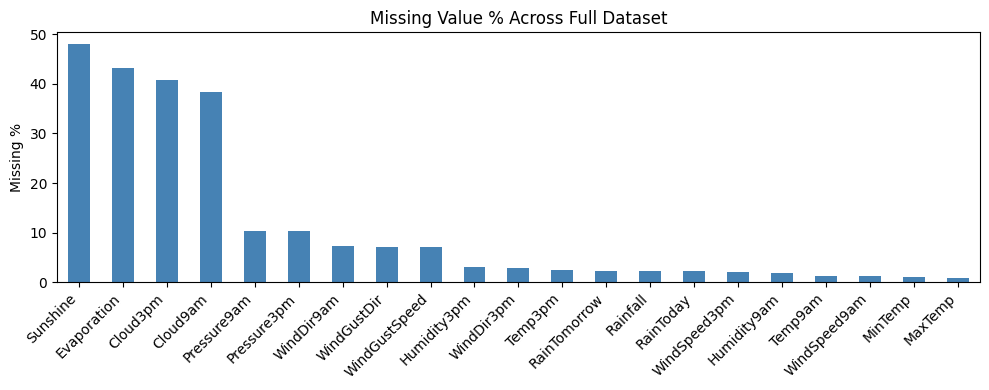

In [18]:
missing_pct = df_all.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

missing_pct.plot(kind="bar", figsize=(10, 4), color="steelblue")
plt.title("Missing Value % Across Full Dataset")
plt.ylabel("Missing %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

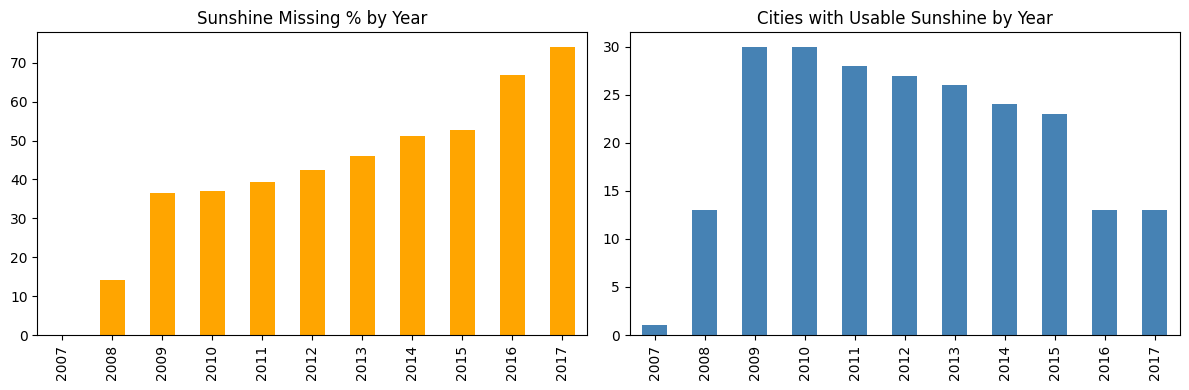

      missing_pct  cities_with_sunshine
Year                                   
2007          0.0                     1
2008         14.2                    13
2009         36.6                    30
2010         37.1                    30
2011         39.3                    28
2012         42.4                    27
2013         46.1                    26
2014         51.2                    24
2015         52.8                    23
2016         66.9                    13
2017         74.1                    13


In [22]:
sunshine_missing = (
    df_all.groupby("Year")["Sunshine"].apply(lambda x: x.isnull().mean() * 100).round(1)
)
cities_with_sunshine = df_all.groupby("Year").apply(
    lambda x: x.groupby("Location")["Sunshine"]
    .apply(lambda s: s.isnull().mean() < 0.5)
    .sum()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sunshine_missing.plot(
    kind="bar", ax=axes[0], color="orange", title="Sunshine Missing % by Year"
)
cities_with_sunshine.plot(
    kind="bar",
    ax=axes[1],
    color="steelblue",
    title="Cities with Usable Sunshine by Year",
)
for ax in axes:
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

print(
    pd.DataFrame(
        {"missing_pct": sunshine_missing, "cities_with_sunshine": cities_with_sunshine}
    )
)

## 3. Train / Holdout Split

**2009 → train**, **2010 → holdout** — best `Sunshine` coverage among all years. `Date` is retained here for monthly PVOUT lookup in Section 5 and dropped before training.

In [23]:
TRAIN_YEAR = 2009
HOLDOUT_YEAR = 2010

df_train = (
    df_all[df_all["Year"] == TRAIN_YEAR].copy().drop(columns=["Year", "RainTomorrow"])
)
df_holdout = (
    df_all[df_all["Year"] == HOLDOUT_YEAR].copy().drop(columns=["Year", "RainTomorrow"])
)

df_holdout_raw = df_holdout.copy()

print(f"Train   : {df_train.shape}  | cities: {df_train['Location'].nunique()}")
print(f"Holdout : {df_holdout.shape} | cities: {df_holdout['Location'].nunique()}")

Train   : (16789, 22)  | cities: 46
Holdout : (16782, 22) | cities: 46


## 4. PVOUT Extraction from Global Solar Atlas

Geocode each city with `geopy` (Nominatim), then extract PVOUT values from the Global Solar Atlas rasters using `rasterio`. Each city's bounding box from Nominatim is used to average all raster pixels within the city's geographic extent.

- **Yearly PVOUT** — for visualization only
- **Monthly PVOUT** — regression target, captures seasonal solar variation
- 44/46 cities resolved (NorfolkIsland outside raster bounds, MountGinini bbox too small)

In [25]:
from geopy.geocoders import Nominatim
import re
import time

geolocator = Nominatim(user_agent="solar_assessment")


def normalize_city(city: str) -> str:
    return re.sub(r"([a-z])([A-Z])", r"\1 \2", city)


cities = df_train["Location"].unique()

city_locations = {}
for city in cities:
    for query in [f"{normalize_city(city)}, Australia", f"{city}, Australia"]:
        try:
            location = geolocator.geocode(query)
            time.sleep(1)
            if location:
                city_locations[city] = location
                break
        except Exception:
            pass

city_coords = {
    city: (loc.latitude, loc.longitude) for city, loc in city_locations.items()
}

failed = [c for c in cities if c not in city_locations]
print(f"Geocoded : {len(city_locations)}/{len(cities)}")
if failed:
    print(f"Failed   : {failed}")

Geocoded : 46/46


In [27]:
from rasterio.mask import mask
from shapely.geometry import box
import rasterio


MONTHLY_PVOUT_DIR = SOLAR_DIR / "monthly"


def extract_pvout_bbox(location_raw: dict, src) -> tuple[float | None, object]:
    """Average PVOUT within the city's Nominatim bounding box."""
    south, north, west, east = [float(x) for x in location_raw["boundingbox"]]
    bbox_geom = box(west, south, east, north)
    try:
        out_image, _ = mask(src, [bbox_geom], crop=True, nodata=src.nodata)
        values = out_image[0].astype(float)
        values[values == src.nodata] = np.nan
        valid = values[~np.isnan(values)]
        return float(valid.mean()) if len(valid) > 0 else None, bbox_geom
    except Exception:
        return None, bbox_geom


city_pvout_monthly = {city: {} for city in city_locations}
city_bboxes = {}

for month in range(1, 13):
    with rasterio.open(MONTHLY_PVOUT_DIR / f"PVOUT_{month:02d}.tif") as src:
        for city, loc in city_locations.items():
            pvout, geom = extract_pvout_bbox(loc.raw, src)
            city_pvout_monthly[city][month] = pvout
            if city not in city_bboxes:
                city_bboxes[city] = geom

extracted = sum(
    1 for m in city_pvout_monthly.values() if any(v is not None for v in m.values())
)
print(f"Monthly PVOUT extracted : {extracted}/{len(city_locations)} cities × 12 months")

Monthly PVOUT extracted : 44/46 cities × 12 months


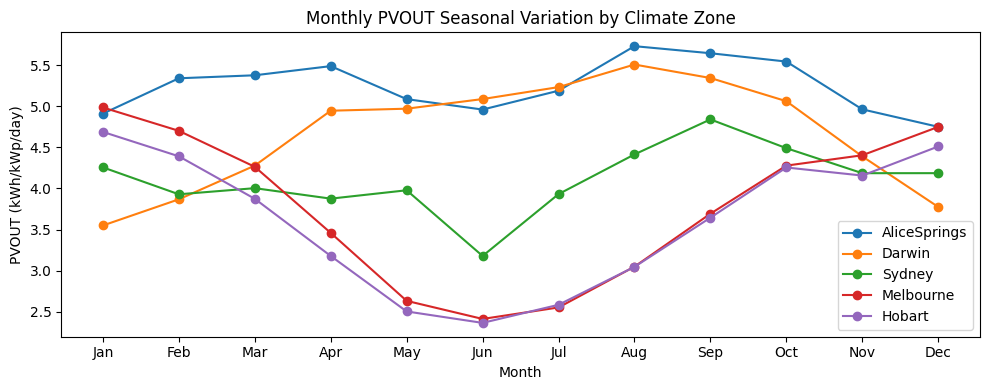

In [40]:
# Seasonal variation — sample cities across climate zones
sample_cities = ["AliceSprings", "Darwin", "Sydney", "Melbourne", "Hobart"]
month_labels = [pd.Timestamp(2010, m, 1).strftime("%b") for m in range(1, 13)]

plt.figure(figsize=(10, 4))
for city in sample_cities:
    if city in city_pvout_monthly:
        vals = [city_pvout_monthly[city].get(m) for m in range(1, 13)]
        plt.plot(range(1, 13), vals, marker="o", label=city)
plt.title("Monthly PVOUT Seasonal Variation by Climate Zone")
plt.xlabel("Month")
plt.ylabel("PVOUT (kWh/kWp/day)")
plt.xticks(range(1, 13), month_labels)
plt.legend()
plt.tight_layout()
plt.show()

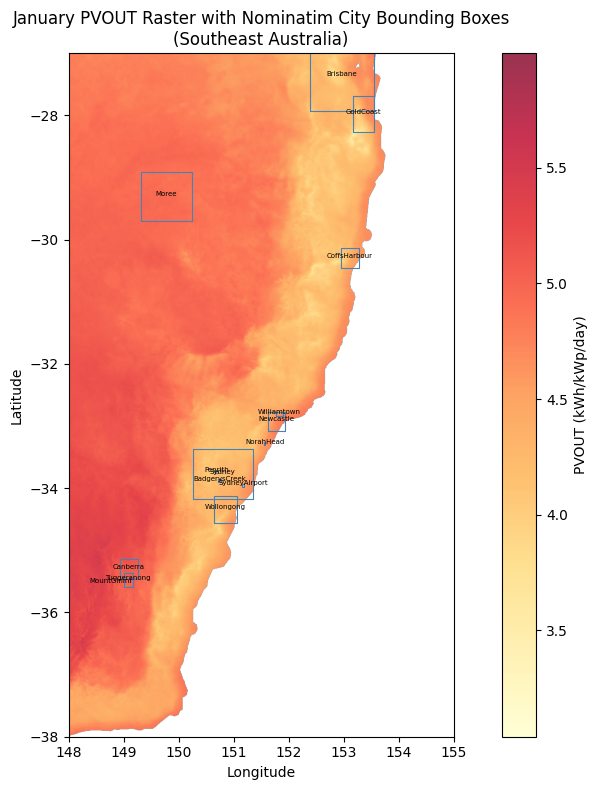

In [44]:
import geopandas as gpd

# Bbox overlay on January PVOUT raster
with rasterio.open(MONTHLY_PVOUT_DIR / "PVOUT_01.tif") as src:
    jan_data = src.read(1)
    jan_data = np.where(jan_data == src.nodata, np.nan, jan_data)

bbox_gdf = gpd.GeoDataFrame(
    [{"city": city, "geometry": geom} for city, geom in city_bboxes.items()],
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(10, 8))
img = ax.imshow(
    jan_data, cmap="YlOrRd", extent=[112, 160, -44, -9], aspect="auto", alpha=0.8
)
plt.colorbar(img, ax=ax, label="PVOUT (kWh/kWp/day)")
bbox_gdf.boundary.plot(ax=ax, color="steelblue", linewidth=0.8)
for _, row in bbox_gdf.iterrows():
    c = row.geometry.centroid
    ax.annotate(row["city"], (c.x, c.y), fontsize=5, ha="center")
ax.set_title(
    "January PVOUT Raster with Nominatim City Bounding Boxes\n(Southeast Australia)"
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(148, 155)
ax.set_ylim(-38, -27)
plt.tight_layout()
plt.show()

## 5. Feature Engineering

Map monthly PVOUT onto each weather row by city + month as the regression target. Drop `Date`, `Location`, and any date-derived columns before training — seasonality is already captured in the monthly target.

In [45]:
CAT_COLS = ["WindGustDir", "WindDir9am", "WindDir3pm", "RainToday"]


def lookup_monthly_pvout(row):
    return city_pvout_monthly.get(row["Location"], {}).get(row["Date"].month)


df_train["PVOUT"] = df_train.apply(lookup_monthly_pvout, axis=1)
df_holdout["PVOUT"] = df_holdout.apply(lookup_monthly_pvout, axis=1)

# Drop Date and Location — not features
df_train = df_train.drop(columns=["Date", "Location"])
df_holdout = df_holdout.drop(columns=["Date", "Location"])

df_train = df_train.dropna(subset=["PVOUT"])
df_holdout = df_holdout.dropna(subset=["PVOUT"])

print(
    f"Train shape   : {df_train.shape} | PVOUT range: {df_train['PVOUT'].min():.2f} – {df_train['PVOUT'].max():.2f}"
)
print(
    f"Holdout shape : {df_holdout.shape} | PVOUT range: {df_holdout['PVOUT'].min():.2f} – {df_holdout['PVOUT'].max():.2f}"
)
print(f"\nPVOUT distribution:")
print(df_train["PVOUT"].describe().round(3))

Train shape   : (16059, 21) | PVOUT range: 2.23 – 5.77
Holdout shape : (16052, 21) | PVOUT range: 2.23 – 5.77

PVOUT distribution:
count    16059.000
mean         4.294
std          0.797
min          2.232
25%          3.853
50%          4.391
75%          4.911
max          5.774
Name: PVOUT, dtype: float64


In [46]:
from sklearn.preprocessing import LabelEncoder

FEATURE_COLS = [c for c in df_train.columns if c != "PVOUT"]

encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    combined = pd.concat([df_train[col], df_holdout[col]]).astype(str)
    le.fit(combined)
    df_train[col] = le.transform(df_train[col].astype(str))
    df_holdout[col] = le.transform(df_holdout[col].astype(str))
    encoders[col] = le

X_train = df_train[FEATURE_COLS]
y_train = df_train["PVOUT"]
X_test = df_holdout[FEATURE_COLS]
y_test = df_holdout["PVOUT"]

print(f"X_train  : {X_train.shape}")
print(f"X_test   : {X_test.shape}")
print(f"Features : {FEATURE_COLS}")

X_train  : (16059, 20)
X_test   : (16052, 20)
Features : ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday']


## 6. Model Training — Baseline XGBoost

Train an initial XGBoost regressor with sensible defaults to establish a performance baseline before tuning.

In [50]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)

y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nRMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

[0]	validation_0-rmse:0.77759
[100]	validation_0-rmse:0.50275
[200]	validation_0-rmse:0.49451
[300]	validation_0-rmse:0.49226
[400]	validation_0-rmse:0.49021
[499]	validation_0-rmse:0.49011

RMSE : 0.4901
MAE  : 0.3814
R²   : 0.6220


## 7. Hyperparameter Tuning with Optuna

100 trials of Bayesian optimisation (TPESampler) over `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, and `min_child_weight`.

In [51]:
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "random_state": 42,
        "n_jobs": -1,
    }
    m = xgb.XGBRegressor(**params)
    m.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    return r2_score(y_test, m.predict(X_test))


study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"Best R²     : {study.best_value:.4f}")
print(f"Best params : {study.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]

Best R²     : 0.6321
Best params : {'n_estimators': 972, 'max_depth': 9, 'learning_rate': 0.015707385483716033, 'subsample': 0.6534003692502202, 'colsample_bytree': 0.7150568927918421, 'min_child_weight': 6}


In [52]:
best_model = xgb.XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)

y_pred_tuned = best_model.predict(X_test)
rmse_tuned = mean_squared_error(y_test, y_pred_tuned) ** 0.5
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"           Baseline → Tuned")
print(f"RMSE : {rmse:.4f}   → {rmse_tuned:.4f}")
print(f"MAE  : {mae:.4f}   → {mae_tuned:.4f}")
print(f"R²   : {r2:.4f}   → {r2_tuned:.4f}")

           Baseline → Tuned
RMSE : 0.4901   → 0.4835
MAE  : 0.3814   → 0.3746
R²   : 0.6220   → 0.6321


## 8. Model Evaluation

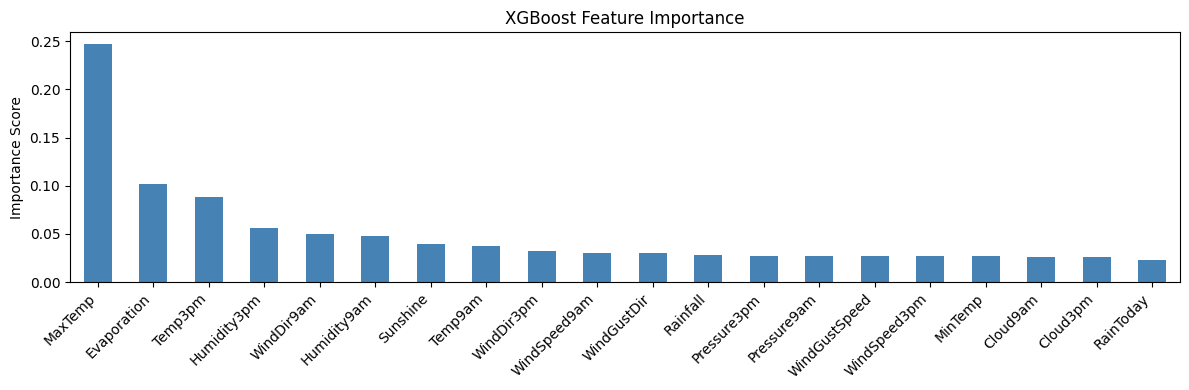

MaxTemp          0.2469
Evaporation      0.1019
Temp3pm          0.0883
Humidity3pm      0.0558
WindDir9am       0.0505
Humidity9am      0.0474
Sunshine         0.0394
Temp9am          0.0370
WindDir3pm       0.0319
WindSpeed9am     0.0303
WindGustDir      0.0300
Rainfall         0.0278
Pressure3pm      0.0276
Pressure9am      0.0275
WindGustSpeed    0.0274
WindSpeed3pm     0.0273
MinTemp          0.0266
Cloud9am         0.0266
Cloud3pm         0.0262
RainToday        0.0235
dtype: float32


In [53]:
importance = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values(
    ascending=False
)

importance.plot(kind="bar", figsize=(12, 4), color="steelblue")
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(importance.round(4))

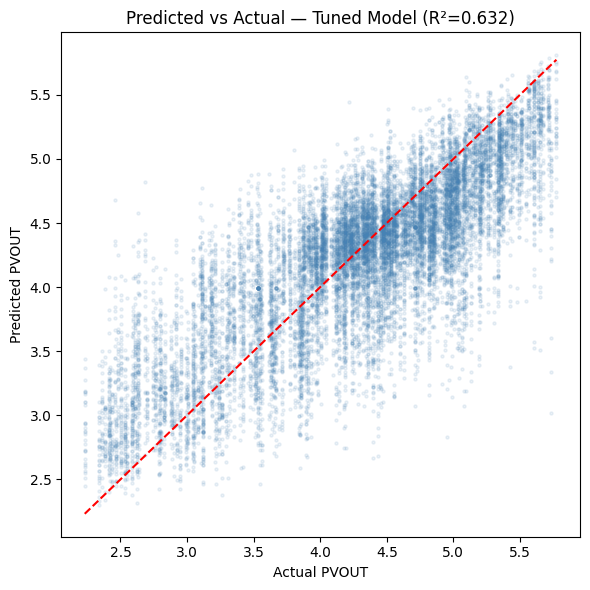

In [54]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.1, s=5, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual PVOUT")
plt.ylabel("Predicted PVOUT")
plt.title(f"Predicted vs Actual — Tuned Model (R²={r2_tuned:.3f})")
plt.tight_layout()
plt.show()

## 8. Save & Verify Artifacts

Persist all artifacts needed by the production agent to `data/processed/`:

| File | Contents |
|---|---|
| `xgb_model.json` | Tuned XGBoost model |
| `encoders.pkl` | LabelEncoder per categorical column |
| `feature_cols.pkl` | Ordered feature column list |
| `holdout_weather.csv` | 2010 holdout rows (historical fallback for agent) |

Reload and re-score to confirm round-trip integrity.

In [59]:
import joblib

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(exist_ok=True)

best_model.save_model(PROCESSED_DIR / "xgb_model.json")
joblib.dump(encoders, PROCESSED_DIR / "encoders.pkl")
joblib.dump(FEATURE_COLS, PROCESSED_DIR / "feature_cols.pkl")
df_holdout_raw.to_csv(PROCESSED_DIR / "holdout_weather.csv", index=False)

print("Saved: xgb_model.json, encoders.pkl, feature_cols.pkl, holdout_weather.csv")

Saved: xgb_model.json, encoders.pkl, feature_cols.pkl, holdout_weather.csv


In [61]:
model_loaded = xgb.XGBRegressor()
model_loaded.load_model(PROCESSED_DIR / "xgb_model.json")
encoders_loaded = joblib.load(PROCESSED_DIR / "encoders.pkl")
feature_cols_loaded = joblib.load(PROCESSED_DIR / "feature_cols.pkl")

y_pred_reload = model_loaded.predict(X_test[feature_cols_loaded])
r2_reload = r2_score(y_test, y_pred_reload)

print(f"Model reload R²   : {r2_reload:.4f}")
print(f"Features          : {len(feature_cols_loaded)}")

Model reload R²   : 0.6321
Features          : 20


In [62]:
X_test

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
396,19.4,31.9,5.0,NaN,NaN,5,39.0,7,14,9.0,9.0,70.0,40.0,1012.2,1008.5,NaN,1.0,23.4,30.9,1
397,18.6,29.1,12.4,NaN,NaN,13,56.0,8,13,6.0,28.0,88.0,48.0,1007.8,1006.2,5.0,NaN,20.6,28.0,1
398,12.2,29.7,0.0,NaN,NaN,13,30.0,11,12,9.0,19.0,57.0,32.0,1014.4,1012.5,NaN,NaN,18.0,28.0,0
399,14.8,32.8,0.0,NaN,NaN,12,30.0,1,6,11.0,9.0,55.0,24.0,1017.5,1013.6,NaN,NaN,21.3,30.6,0
400,15.0,35.8,0.0,NaN,NaN,13,46.0,0,7,4.0,17.0,46.0,13.0,1014.9,1011.5,NaN,NaN,23.3,34.9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140020,22.5,27.6,55.2,5.6,0.2,14,39.0,3,14,4.0,24.0,90.0,87.0,1003.1,1001.3,7.0,7.0,25.8,26.5,1
140021,24.3,29.3,33.4,0.8,0.7,14,41.0,16,13,0.0,19.0,84.0,76.0,1003.7,1002.0,7.0,8.0,26.8,28.0,1
140022,24.1,31.0,16.4,2.4,0.8,15,37.0,15,14,15.0,22.0,82.0,66.0,1005.9,1002.9,7.0,7.0,27.5,30.0,1
140023,23.8,30.5,18.0,4.8,1.4,11,44.0,13,3,9.0,19.0,79.0,72.0,1006.5,1003.9,7.0,7.0,27.0,29.6,1
